In [239]:
import numpy as np
import pandas as pd
import torch
from sklearn.impute import SimpleImputer 
import matplotlib.pyplot as plt
simple_imputer = SimpleImputer()
from sklearn.model_selection import train_test_split
from torch import nn
from sklearn.preprocessing import StandardScaler

In [240]:
housing = pd.read_csv("./housing.csv")
housing_cleaned = housing.copy()
print(housing_cleaned.shape)
housing_cleaned.dropna(inplace=True)
print(housing.shape)
housing.head()

(1000, 10)
(1000, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [241]:
housing_cleaned = pd.get_dummies(housing_cleaned,columns=["ocean_proximity"],drop_first=True,dtype=int)

In [242]:
housing_num =simple_imputer.fit_transform(housing_cleaned)

In [243]:
housing_cleaned

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_NEAR BAY
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,1
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,1
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,1
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,1
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
995,-121.75,37.71,11.0,12070.0,2220.0,5826.0,2125.0,4.8624,192400.0,1,0
996,-121.77,37.74,25.0,494.0,81.0,254.0,85.0,9.1531,418800.0,1,0
997,-121.80,37.70,22.0,5533.0,943.0,2474.0,910.0,4.7361,216800.0,1,0
998,-121.80,37.69,17.0,3956.0,639.0,2222.0,662.0,5.4324,215500.0,1,0


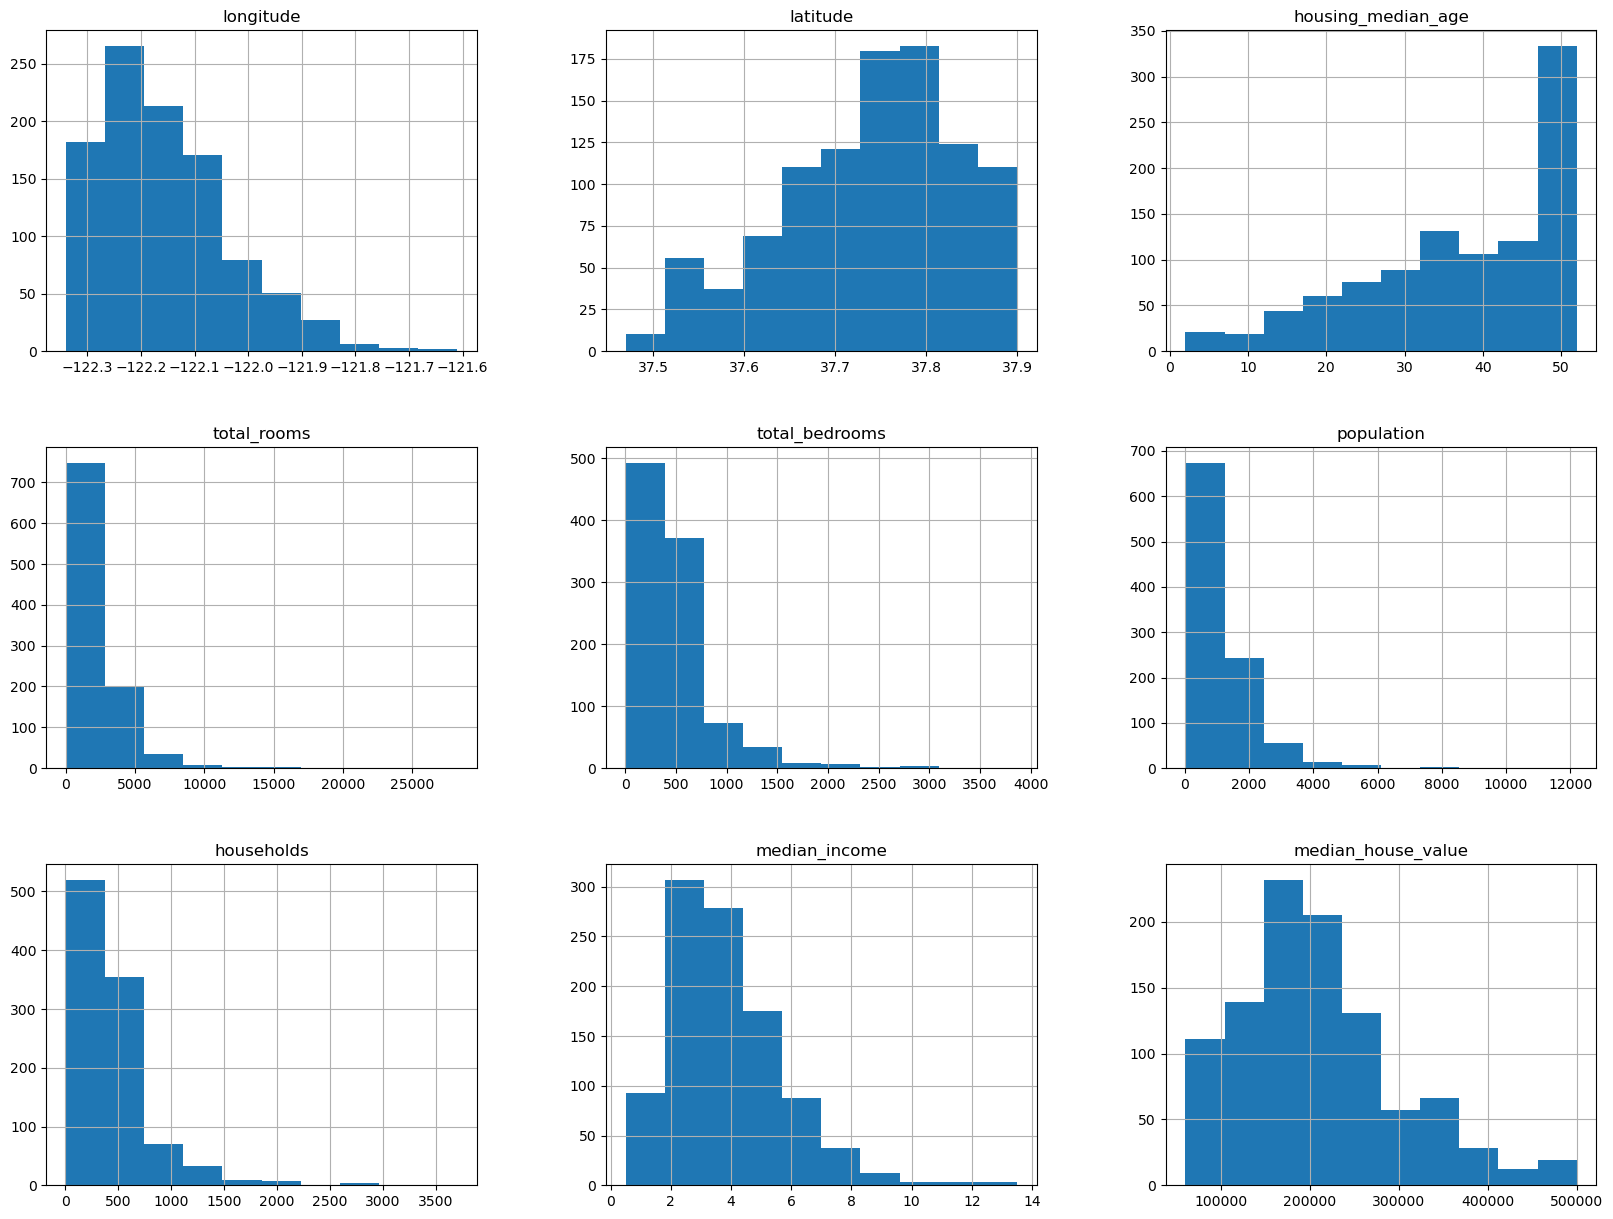

In [244]:
housing.hist(figsize=(20,15))
plt.show()

In [245]:
X = housing_cleaned.drop(columns=["median_house_value"])
y = housing_cleaned[["median_house_value"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
y_scaler = StandardScaler()
y_scaled  = y_scaler.fit_transform(y)

X = torch.from_numpy(np.array(X_scaled)).type(dtype=torch.float32)
y = torch.from_numpy(np.array(y_scaled)).type(dtype=torch.float32)
print(X.shape)

torch.Size([994, 10])


In [246]:
X_train,X_test,y_train,y_test  = train_test_split(X,y,test_size=0.2,)


In [247]:
class CommonModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.Layer1 = nn.Linear(in_features=10, out_features=20)
        self.Layer2 = nn.Linear(in_features=20, out_features=16)
        self.Layer3 = nn.Linear(in_features=16, out_features=1)
        self.ReLU = nn.ReLU()

    def forward(self, X):
        return self.Layer3(self.ReLU(self.Layer2(self.ReLU(self.Layer1(X)))))

In [248]:
torch.manual_seed(42)
model25 = CommonModel()
model25.state_dict()

OrderedDict([('Layer1.weight',
              tensor([[ 0.2418,  0.2625, -0.0741,  0.2905, -0.0693,  0.0638, -0.1540,  0.1857,
                        0.2788, -0.2320],
                      [ 0.2749,  0.0592,  0.2336,  0.0428,  0.1525, -0.0446,  0.2438,  0.0467,
                       -0.1476,  0.0806],
                      [-0.1457, -0.0371, -0.1284,  0.2098, -0.2496, -0.1458, -0.0893, -0.1901,
                        0.0298, -0.3123],
                      [ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1310,  0.1000, -0.0055,
                        0.2475, -0.2247],
                      [ 0.0199, -0.2158,  0.0975, -0.1089,  0.0969, -0.0659,  0.2623, -0.1874,
                       -0.1886, -0.1886],
          

In [249]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(params=model25.parameters(), lr=0.01)

In [250]:
epochs = 2000

for epoch in range(epochs):
    model25.train()
    y_preds = model25(X_train)
    loss = loss_fn(y_preds, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model25.eval()  
    with torch.inference_mode():
        test_preds = model25(X_test)
        test_loss = loss_fn(test_preds, y_test)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss.item()} | Test Loss: {test_loss}")

Epoch: 0 | Loss: 1.0558810234069824 | Test Loss: 1.0804787874221802
Epoch: 10 | Loss: 0.571764349937439 | Test Loss: 0.7206584811210632
Epoch: 20 | Loss: 0.36067989468574524 | Test Loss: 0.559824526309967
Epoch: 30 | Loss: 0.29275697469711304 | Test Loss: 0.4643600583076477
Epoch: 40 | Loss: 0.2788599133491516 | Test Loss: 0.4470183849334717
Epoch: 50 | Loss: 0.265887588262558 | Test Loss: 0.4494397044181824
Epoch: 60 | Loss: 0.2581998109817505 | Test Loss: 0.45361530780792236
Epoch: 70 | Loss: 0.2510300278663635 | Test Loss: 0.4541955590248108
Epoch: 80 | Loss: 0.24373428523540497 | Test Loss: 0.45001572370529175
Epoch: 90 | Loss: 0.23655180633068085 | Test Loss: 0.4480774402618408
Epoch: 100 | Loss: 0.22914543747901917 | Test Loss: 0.44264212250709534
Epoch: 110 | Loss: 0.22118116915225983 | Test Loss: 0.4332197904586792
Epoch: 120 | Loss: 0.2124754637479782 | Test Loss: 0.4255290925502777
Epoch: 130 | Loss: 0.2031683623790741 | Test Loss: 0.4106833040714264
Epoch: 140 | Loss: 0.1937

Epoch 0 | Train Loss 0.8933 | Test Loss 0.6819
Epoch 50 | Train Loss 0.2293 | Test Loss 0.2318
Epoch 100 | Train Loss 0.1804 | Test Loss 0.2094
Epoch 150 | Train Loss 0.1464 | Test Loss 0.1898
Epoch 200 | Train Loss 0.1198 | Test Loss 0.1992
Epoch 250 | Train Loss 0.1005 | Test Loss 0.1896


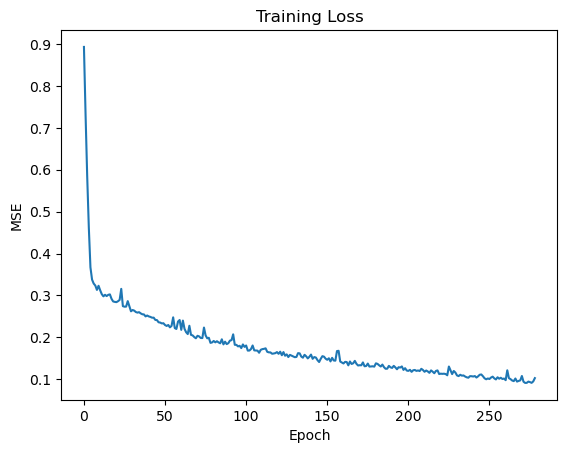

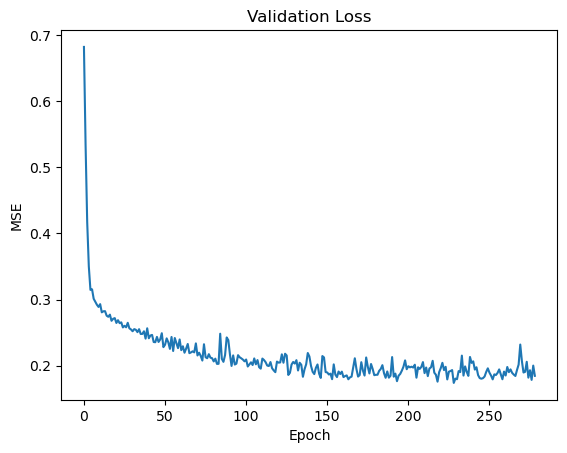

Final RMSE in dollars: 38861.0667489162


In [251]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

housing = pd.read_csv("./housing.csv")
housing = housing.dropna()
housing = pd.get_dummies(
    housing, columns=["ocean_proximity"], drop_first=True, dtype=int
)

X = housing.drop(columns=["median_house_value"]).values
y = housing[["median_house_value"]].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)


class Model(nn.Module):
    def __init__(self, in_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
model = Model(X_train.shape[1])

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 800
train_losses = []
test_losses = []

best_loss = float("inf")
patience = 50
counter = 0

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for xb, yb in train_loader:
        preds = model(xb)
        loss = loss_fn(preds, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    epoch_loss /= len(train_loader)
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test)
        test_loss = loss_fn(test_preds, y_test).item()
    train_losses.append(epoch_loss)
    test_losses.append(test_loss)
    if test_loss < best_loss:
        best_loss = test_loss
        counter = 0
    else:
        counter += 1
    if counter >= patience:
        break
    if epoch % 50 == 0:
        print(
            f"Epoch {epoch} | Train Loss {epoch_loss:.4f} | Test Loss {test_loss:.4f}"
        )

plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

plt.figure()
plt.plot(test_losses)
plt.title("Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

model.eval()
with torch.no_grad():
    preds = model(X_test)
    rmse_scaled = torch.sqrt(loss_fn(preds, y_test)).item()

rmse_real = rmse_scaled * y_scaler.scale_[0]
print("Final RMSE in dollars:", rmse_real)